# Relational structure — households, neighbor edges & the typed graph

The flat EDA notebook treats each door as an i.i.d. row. The **relational** dataset adds the
structure the flat world throws away: doors are grouped into **households**, near doors are joined
by **neighbor edges**, some neighbors **share a competitor**, and each prospect carries an
**interaction history**. This notebook explores that substrate directly from the sidecar artifacts
written by `scripts/generate_relational_logs.py` (`households.parquet`, `edges.parquet`,
`graph.npz`) — the inputs a future relational model (Phase 14) would learn on.

> This notebook is relational-only by nature. The schema-identical `logs.parquet` is still the
> contract every learner consumes; the structure here lives *alongside* it.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nba.data.graph import GRAPH_EDGE_TYPES, load_graph

RNG = np.random.default_rng(7)


def _resolve(rel):
    p = Path(rel)
    return p if p.exists() else Path("..") / rel


REL = _resolve("data/relational")
assert (REL / "logs.parquet").exists(), (
    "Relational dataset not found. Generate it first:\n"
    "  uv run python scripts/generate_relational_logs.py --n 8000 --seed 7 --out data/relational"
)

logs = pd.read_parquet(REL / "logs.parquet")
households = pd.read_parquet(REL / "households.parquet")
edges = pd.read_parquet(REL / "edges.parquet")
graph = load_graph(REL / "graph.npz")
coords = logs.set_index("ctx.address_id")[["ctx.lat", "ctx.lon"]]
print(f"doors={len(logs):,}  households={len(households):,}  edges={len(edges):,}")

doors=100,000  households=33,334  edges=3,723,849


## 1. Households — the account nodes

Doors are clustered into spatially-coherent households (one account a rep might serve as a unit).
The size distribution shows how much grouping exists; the `household_id` column on `logs.parquet`
links every door back to its household without touching the model contract.


count    33334.00
mean         3.00
std          1.81
min          1.00
25%          1.00
50%          3.00
75%          4.00
max         12.00
Name: n_doors, dtype: float64


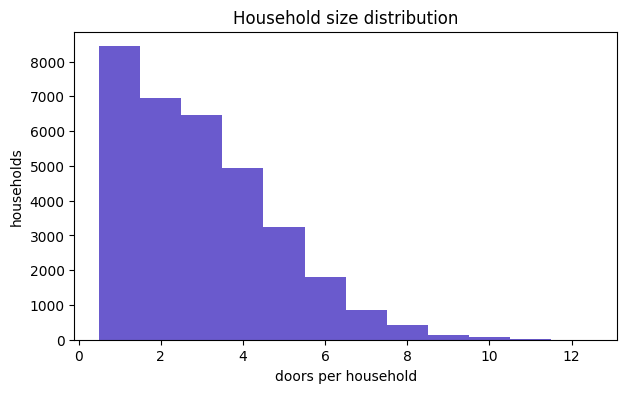

In [2]:
sizes = households["n_doors"]
print(sizes.describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sizes, bins=range(1, int(sizes.max()) + 2), color="slateblue", align="left")
ax.set(title="Household size distribution", xlabel="doors per household", ylabel="households")
plt.show()

## 2. Edges — three typed relations

`edges.parquet` carries the homogeneous door-door relations: **near** (spatial proximity within
`neighbor_radius_km`), **same_household** (co-membership), and **shares_competitor** (a competitor
overlap among neighbors). The neighbor **degree** distribution and the coverage (fraction of doors
with at least one neighbor) tell us how connected the world is — the signal a graph model exploits.


edge_type
near                 3412320
shares_competitor     157043
same_household        154486
Name: count, dtype: int64


doors with >=1 near edge: 99.2%


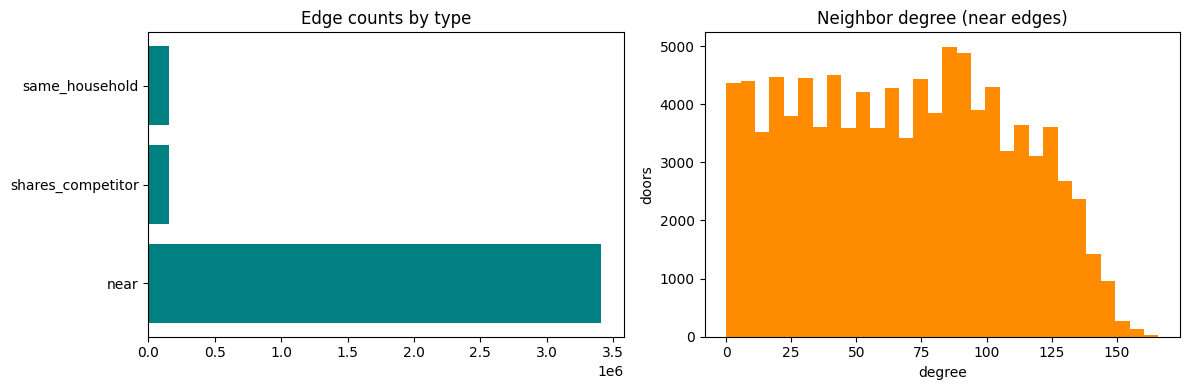

In [3]:
counts = edges["edge_type"].value_counts()
print(counts)

near = edges[edges["edge_type"] == "near"]
near_deg = pd.concat([near["src"], near["dst"]]).value_counts().reindex(coords.index).fillna(0)
print(f"doors with >=1 near edge: {(near_deg > 0).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(counts.index, counts.to_numpy(), color="teal")
ax[0].set_title("Edge counts by type")
ax[1].hist(near_deg.to_numpy(), bins=30, color="darkorange")
ax[1].set(title="Neighbor degree (near edges)", xlabel="degree", ylabel="doors")
plt.tight_layout()
plt.show()

## 3. The typed graph tensors

`graph.npz` is the model-ready view: per-node-type feature matrices and per-edge-type index
tensors. Crucially, the door feature matrix is built from the **same allow-list** the flat model
uses — `lat`/`lon`/`address_id` and any protected field are excluded *by construction*, so no
forbidden attribute can enter a node feature or propagate along an edge.


In [4]:
print("node feature matrices:")
for ntype, feats in graph.node_features.items():
    print(f"  {ntype:<10} {feats.shape}")
print("edge index tensors:")
for etype in GRAPH_EDGE_TYPES:
    print(f"  {etype:<18} {graph.edge_index[etype].shape[1]} edges")

from nba.data.features import ALLOWED_FEATURES  # noqa: E402

print(
    f"\ndoor features mirror the model allow-list ({len(ALLOWED_FEATURES)} fields); "
    "no lat/lon/address_id present."
)

node feature matrices:
  door       (100000, 11)
  household  (33334, 1)
edge index tensors:
  near               3412320 edges
  same_household     154486 edges
  shares_competitor  157043 edges
  interacted         44926 edges

door features mirror the model allow-list (11 fields); no lat/lon/address_id present.


## 4. A walkable neighborhood

Zoom into one dense patch: the 120 doors nearest a random center, with their **near** edges drawn
and points coloured by household. This is the local structure social-proof and household-momentum
effects act on in the relational oracle.


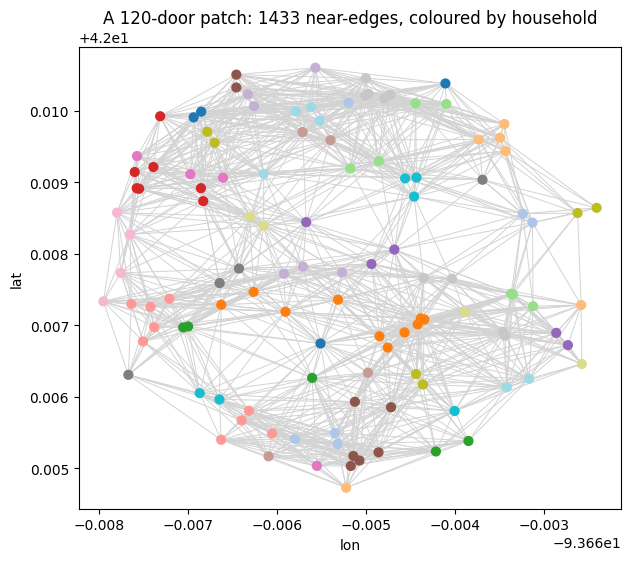

In [5]:
addr_household = {}
for _, row in households.iterrows():
    for addr in row["address_ids"].split(","):
        addr_household[addr] = row["household_id"]

center = coords.iloc[RNG.integers(len(coords))]
d2 = (coords["ctx.lat"] - center["ctx.lat"]) ** 2 + (coords["ctx.lon"] - center["ctx.lon"]) ** 2
patch = coords.loc[d2.nsmallest(120).index]
patch_set = set(patch.index)
patch_near = near[near["src"].isin(patch_set) & near["dst"].isin(patch_set)]

hh_ids = sorted({addr_household.get(a, "?") for a in patch.index})
palette = {h: plt.cm.tab20(i % 20) for i, h in enumerate(hh_ids)}
colors = [palette[addr_household.get(a, "?")] for a in patch.index]

fig, ax = plt.subplots(figsize=(7, 6))
for _, e in patch_near.iterrows():
    a, b = coords.loc[e["src"]], coords.loc[e["dst"]]
    ax.plot(
        [a["ctx.lon"], b["ctx.lon"]],
        [a["ctx.lat"], b["ctx.lat"]],
        color="lightgray",
        lw=0.7,
        zorder=1,
    )
ax.scatter(patch["ctx.lon"], patch["ctx.lat"], c=colors, s=40, zorder=3)
ax.set(
    title=f"A 120-door patch: {len(patch_near)} near-edges, coloured by household",
    xlabel="lon",
    ylabel="lat",
)
plt.show()

## 5. Takeaways

- The relational dataset is a genuine **graph**, not just a flat table: households group doors,
  neighbor edges connect them spatially, and a fraction share a competitor.
- All of it rides **alongside** a schema-identical `logs.parquet` (plus a non-model `household_id`
  column), so every existing learner runs unchanged while a future relational model can consume the
  `graph.npz` substrate.
- Node features obey the **same ethics allow-list** as the flat model — structure adds relations,
  never forbidden attributes.
